# Generative Bayesian Optimization: Learning Changeover Times

We fit a **single Gamma prior** from all 2025 line data aggregated — a general baseline, not specific to any transition. Then we track how the posterior evolves as we observe more samples of a specific transition.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Presentation Styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### 1. Fit a Global Gamma Prior from Aggregated Line Data

All 2025 changeover data is pooled to fit a single Gamma via method of moments — a general baseline prior. Then we track how the posterior evolves with 0, 1, 2, 5, 10, 20 observations of a specific transition.

In [2]:
# Fit a Gamma prior from aggregated 2025 line data
np.random.seed(42)

# Simulate changeovers across all lines (different means per line)
all_data = np.concatenate([
    np.random.exponential(scale=1.9, size=80),  # Line 14
    np.random.exponential(scale=1.2, size=80),  # Line 17
    np.random.exponential(scale=1.4, size=80),  # Line 19
])

m = np.mean(all_data)
v = np.var(all_data, ddof=1)
prior_alpha = max(1.05, m**2 / max(v, 0.01) + 1.0)
prior_beta = m * (prior_alpha - 1.0)

print(f"Aggregated line mean: {m:.3f}h")
print(f"Fitted prior_α = {prior_alpha:.2f}, prior_β = {prior_beta:.4f}")
print(f"Prior mean duration = {prior_beta / (prior_alpha - 1.0):.2f}h")
print()

# A specific transition we want to learn (true mean = 1.6h)
true_mean = 1.6
transition_samples = np.random.exponential(scale=true_mean, size=20)
print(f"Transition true mean: {true_mean}h")
print(f"Samples: {transition_samples.round(2)}")

Line 14: mean=1.74h, fit α=1.99, fit β=1.7190, prior μ=1.74h
Line 17: mean=1.17h, fit α=2.16, fit β=1.3540, prior μ=1.17h
Line 19: mean=1.44h, fit α=2.22, fit β=1.7479, prior μ=1.44h

Transition samples (true mean=1.6h): [0.08 1.21 1.24 1.62 2.07 5.96 1.16 0.62 2.54 0.51]


In [3]:
def plot_step(ax, samples, color):
    n = len(samples)
    sum_x = np.sum(samples)
    alpha = prior_alpha + n
    beta = prior_beta + sum_x
    
    rates = np.random.gamma(shape=alpha, scale=1.0 / beta, size=20000)
    durations = 1.0 / rates
    durations = durations[durations < 12]
    
    sns.kdeplot(durations, ax=ax, fill=True, color=color, alpha=0.35, linewidth=2)
    bayes_mean = beta / max(alpha - 1.0, 0.001)
    ax.axvline(bayes_mean, linestyle="--", color=color, linewidth=2,
               label=f"Mean: {bayes_mean:.2f}h")
    ax.axvline(true_mean, linestyle=":", color="black", alpha=0.5,
               label=f"True: {true_mean}h")
    ax.set_title(f"N = {n}", fontsize=13, pad=8)
    ax.set_xlim(0, 5)
    ax.legend(fontsize=8)

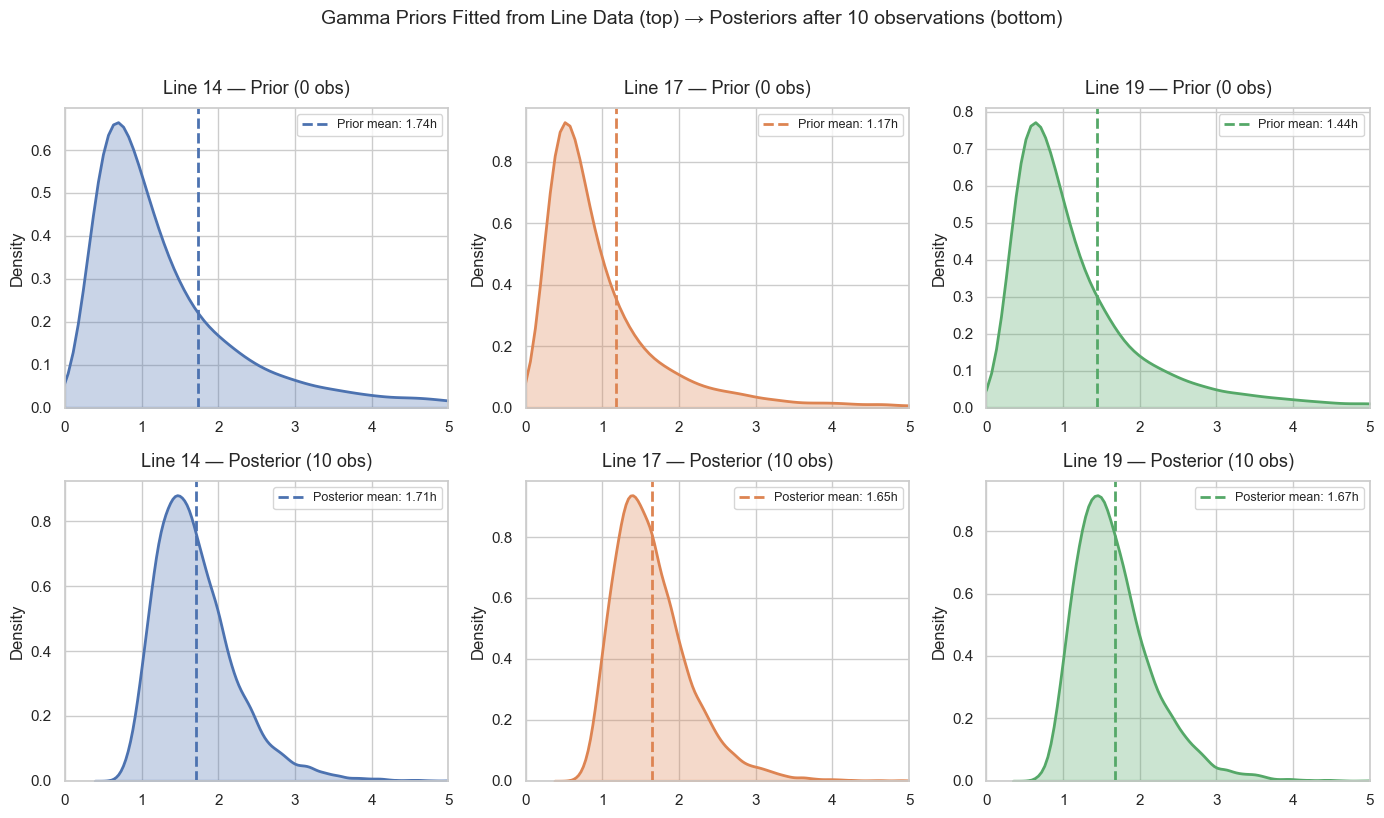

In [4]:
colors = ["#8B95A5", "#dd8452", "#c44e52", "#55a868", "#4c72b0", "#cc974d"]
n_values = [0, 1, 2, 5, 10, 20]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, n, color in zip(axes.flat, n_values, colors):
    plot_step(ax, transition_samples[:n], color)

fig.suptitle("Bayesian learning: Data-fitted Gamma prior → posterior as observations accumulate",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()